# Batch experiment plots

This notebook reads the newest `experiment-runs-*.csv` and `experiment-aggregates-*.csv` in `cmd/batch_sim/outputs`. Generate a fresh pair with:

```sh
go run ./cmd/batch_sim -output-dir cmd/batch_sim/outputs
```

Set `RUNS_CSV` or `AGGREGATES_CSV` in the next cell to inspect a specific historical export. The plots below render every workload, policy, and evaluator combination found in the selected CSVs.

In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 100)

# Leave these as None to use the newest CSVs in cmd/batch_sim/outputs.
RUNS_CSV = None
AGGREGATES_CSV = None


def repository_root(start=Path.cwd()):
    for directory in (start, *start.parents):
        if (directory / "cmd" / "batch_sim").is_dir():
            return directory
    raise FileNotFoundError("Could not find the repository root (expected cmd/batch_sim).")


ROOT = repository_root()
OUTPUTS_DIR = ROOT / "cmd" / "batch_sim" / "outputs"


def newest_csv(prefix):
    candidates = list(OUTPUTS_DIR.glob(f"{prefix}-*.csv"))
    if not candidates:
        raise FileNotFoundError(f"No {prefix}-*.csv found in {OUTPUTS_DIR}")
    return max(candidates, key=lambda path: path.stat().st_mtime)


runs_path = Path(RUNS_CSV) if RUNS_CSV else newest_csv("experiment-runs")
aggregates_path = (
    Path(AGGREGATES_CSV) if AGGREGATES_CSV else newest_csv("experiment-aggregates")
)
runs = pd.read_csv(runs_path)
aggregates = pd.read_csv(aggregates_path)

required_runs = {"workload", "policy", "seed", "evaluation", "value"}
required_aggregates = {"workload", "policy", "evaluation", "mean"}
if missing := required_runs - set(runs.columns):
    raise ValueError(f"Run CSV is missing columns: {sorted(missing)}")
if missing := required_aggregates - set(aggregates.columns):
    raise ValueError(f"Aggregate CSV is missing columns: {sorted(missing)}")

runs["seed"] = pd.to_numeric(runs["seed"])
runs["value"] = pd.to_numeric(runs["value"])
aggregates["mean"] = pd.to_numeric(aggregates["mean"])

print(f"Runs:       {runs_path}")
print(f"Aggregates: {aggregates_path}")
print(f"Workloads:  {', '.join(sorted(aggregates.workload.unique()))}")
print(f"Policies:   {', '.join(sorted(aggregates.policy.unique()))}")
print(f"Evaluators: {', '.join(sorted(aggregates.evaluation.unique()))}")

workloads = sorted(aggregates.workload.unique())
policies = sorted(aggregates.policy.unique())
evaluators = sorted(aggregates.evaluation.unique())

Runs:       /Users/Natha/source/repos/projects/packing_simulator/cmd/batch_sim/outputs/experiment-runs-20260907T194009.529895000Z.csv
Aggregates: /Users/Natha/source/repos/projects/packing_simulator/cmd/batch_sim/outputs/experiment-aggregates-20260907T194009.529917000Z.csv
Workloads:  flat-boxes, mostly-large, mostly-small
Policies:   bottom-left, largest-area-bottom-left
Evaluators: Container fragmentation, Container utilization, Future fit probability


In [20]:
print(
    f"Plotting {len(workloads)} workloads × {len(policies)} policies × "
    f"{len(evaluators)} evaluators = "
    f"{len(workloads) * len(policies) * len(evaluators)} combinations."
)

Plotting 3 workloads × 2 policies × 3 evaluators = 18 combinations.


## 1. Aggregate score for every policy across evaluators

Each subplot is one workload/policy pair; its bars are the aggregate scores for every evaluator.

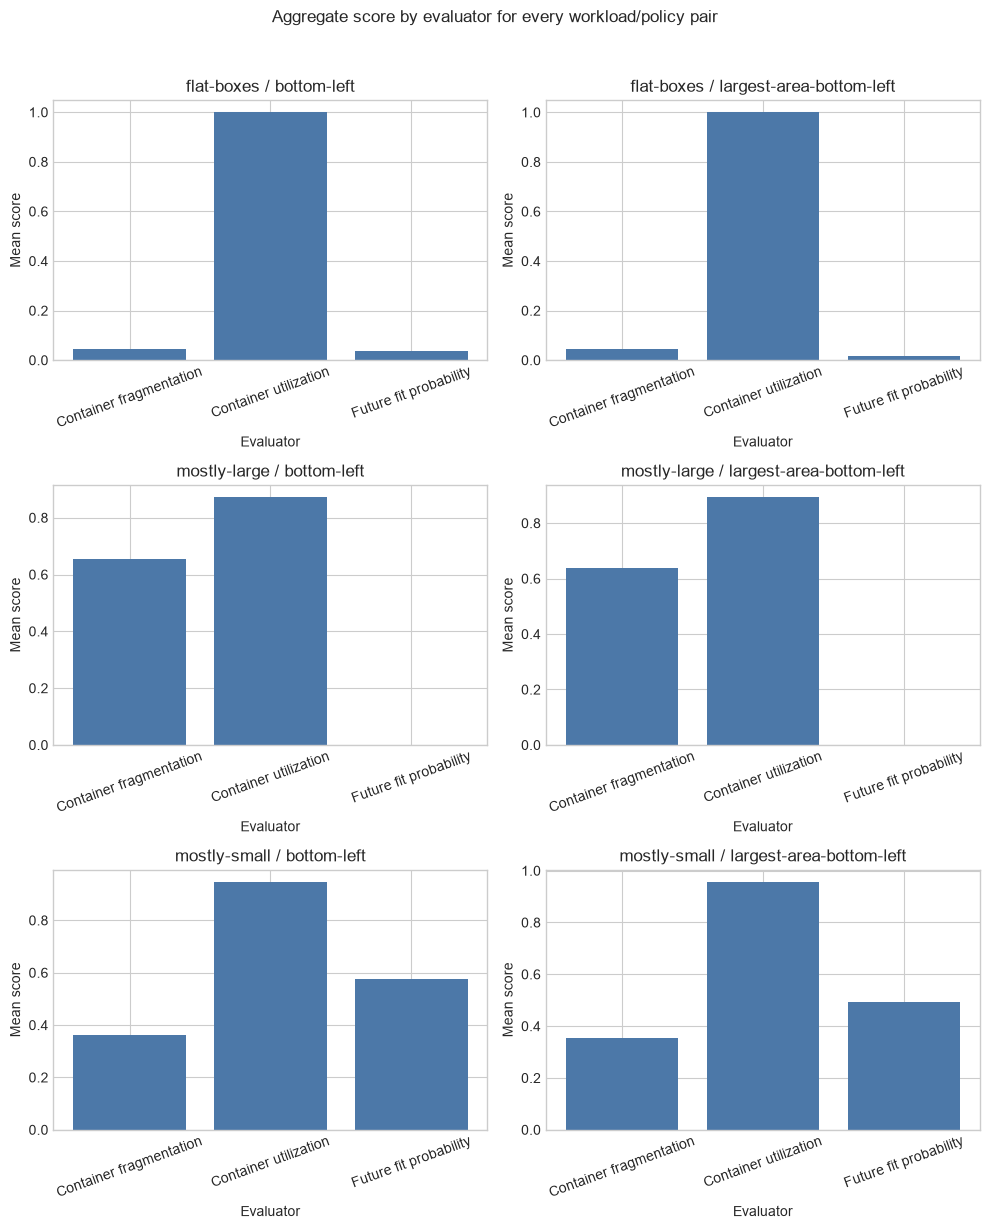

In [21]:
fig, axes = plt.subplots(
    len(workloads), len(policies), squeeze=False, figsize=(5 * len(policies), 4 * len(workloads))
)
for row, workload_name in enumerate(workloads):
    for col, policy_name in enumerate(policies):
        ax = axes[row, col]
        scores = aggregates[
            (aggregates["workload"] == workload_name)
            & (aggregates["policy"] == policy_name)
        ].set_index("evaluation")["mean"].reindex(evaluators)
        ax.bar(evaluators, scores, color="#4C78A8")
        ax.set(title=f"{workload_name} / {policy_name}", xlabel="Evaluator", ylabel="Mean score")
        ax.tick_params(axis="x", rotation=20)
fig.suptitle("Aggregate score by evaluator for every workload/policy pair", y=1.02)
fig.tight_layout()
plt.show()

## 2. Aggregate score for every evaluator across policies

Each subplot is one workload/evaluator pair; its bars are the aggregate scores for every policy.

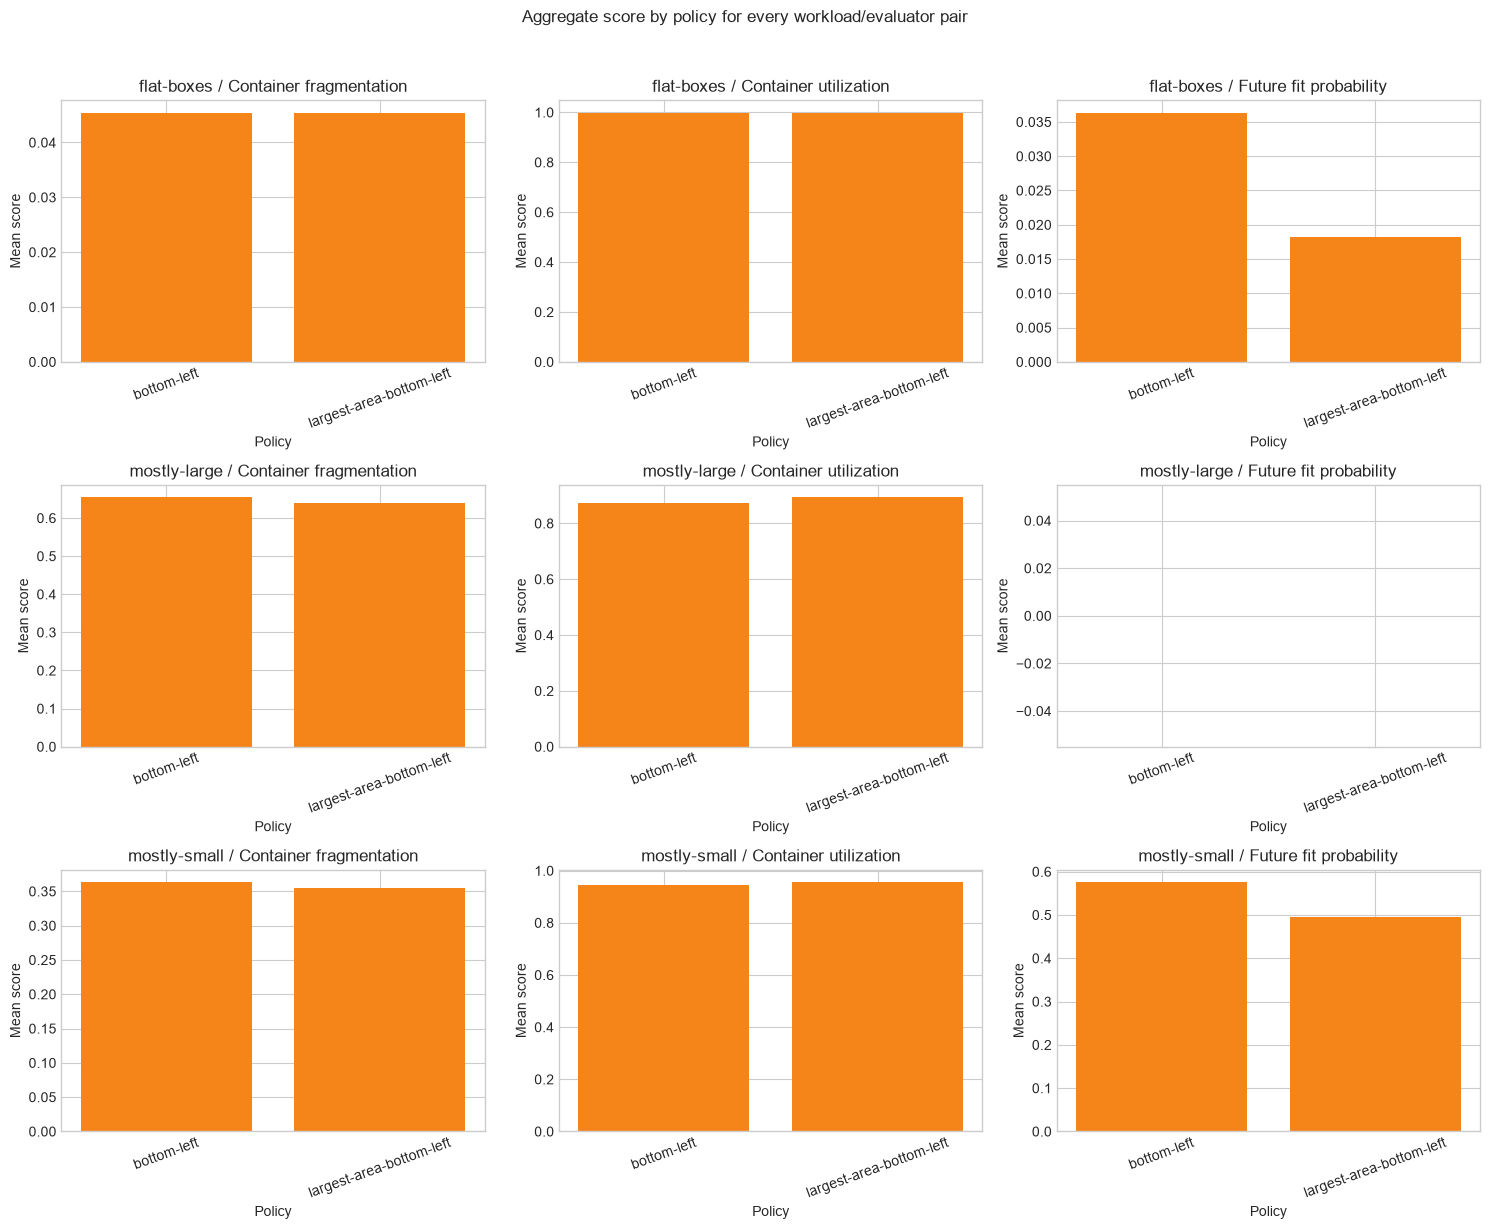

In [22]:
fig, axes = plt.subplots(
    len(workloads), len(evaluators), squeeze=False, figsize=(5 * len(evaluators), 4 * len(workloads))
)
for row, workload_name in enumerate(workloads):
    for col, evaluator_name in enumerate(evaluators):
        ax = axes[row, col]
        scores = aggregates[
            (aggregates["workload"] == workload_name)
            & (aggregates["evaluation"] == evaluator_name)
        ].set_index("policy")["mean"].reindex(policies)
        ax.bar(policies, scores, color="#F58518")
        ax.set(title=f"{workload_name} / {evaluator_name}", xlabel="Policy", ylabel="Mean score")
        ax.tick_params(axis="x", rotation=20)
fig.suptitle("Aggregate score by policy for every workload/evaluator pair", y=1.02)
fig.tight_layout()
plt.show()

## 3. Per-seed score for every workload/policy/evaluator combination

Each row is a workload/policy pair and each column is an evaluator.

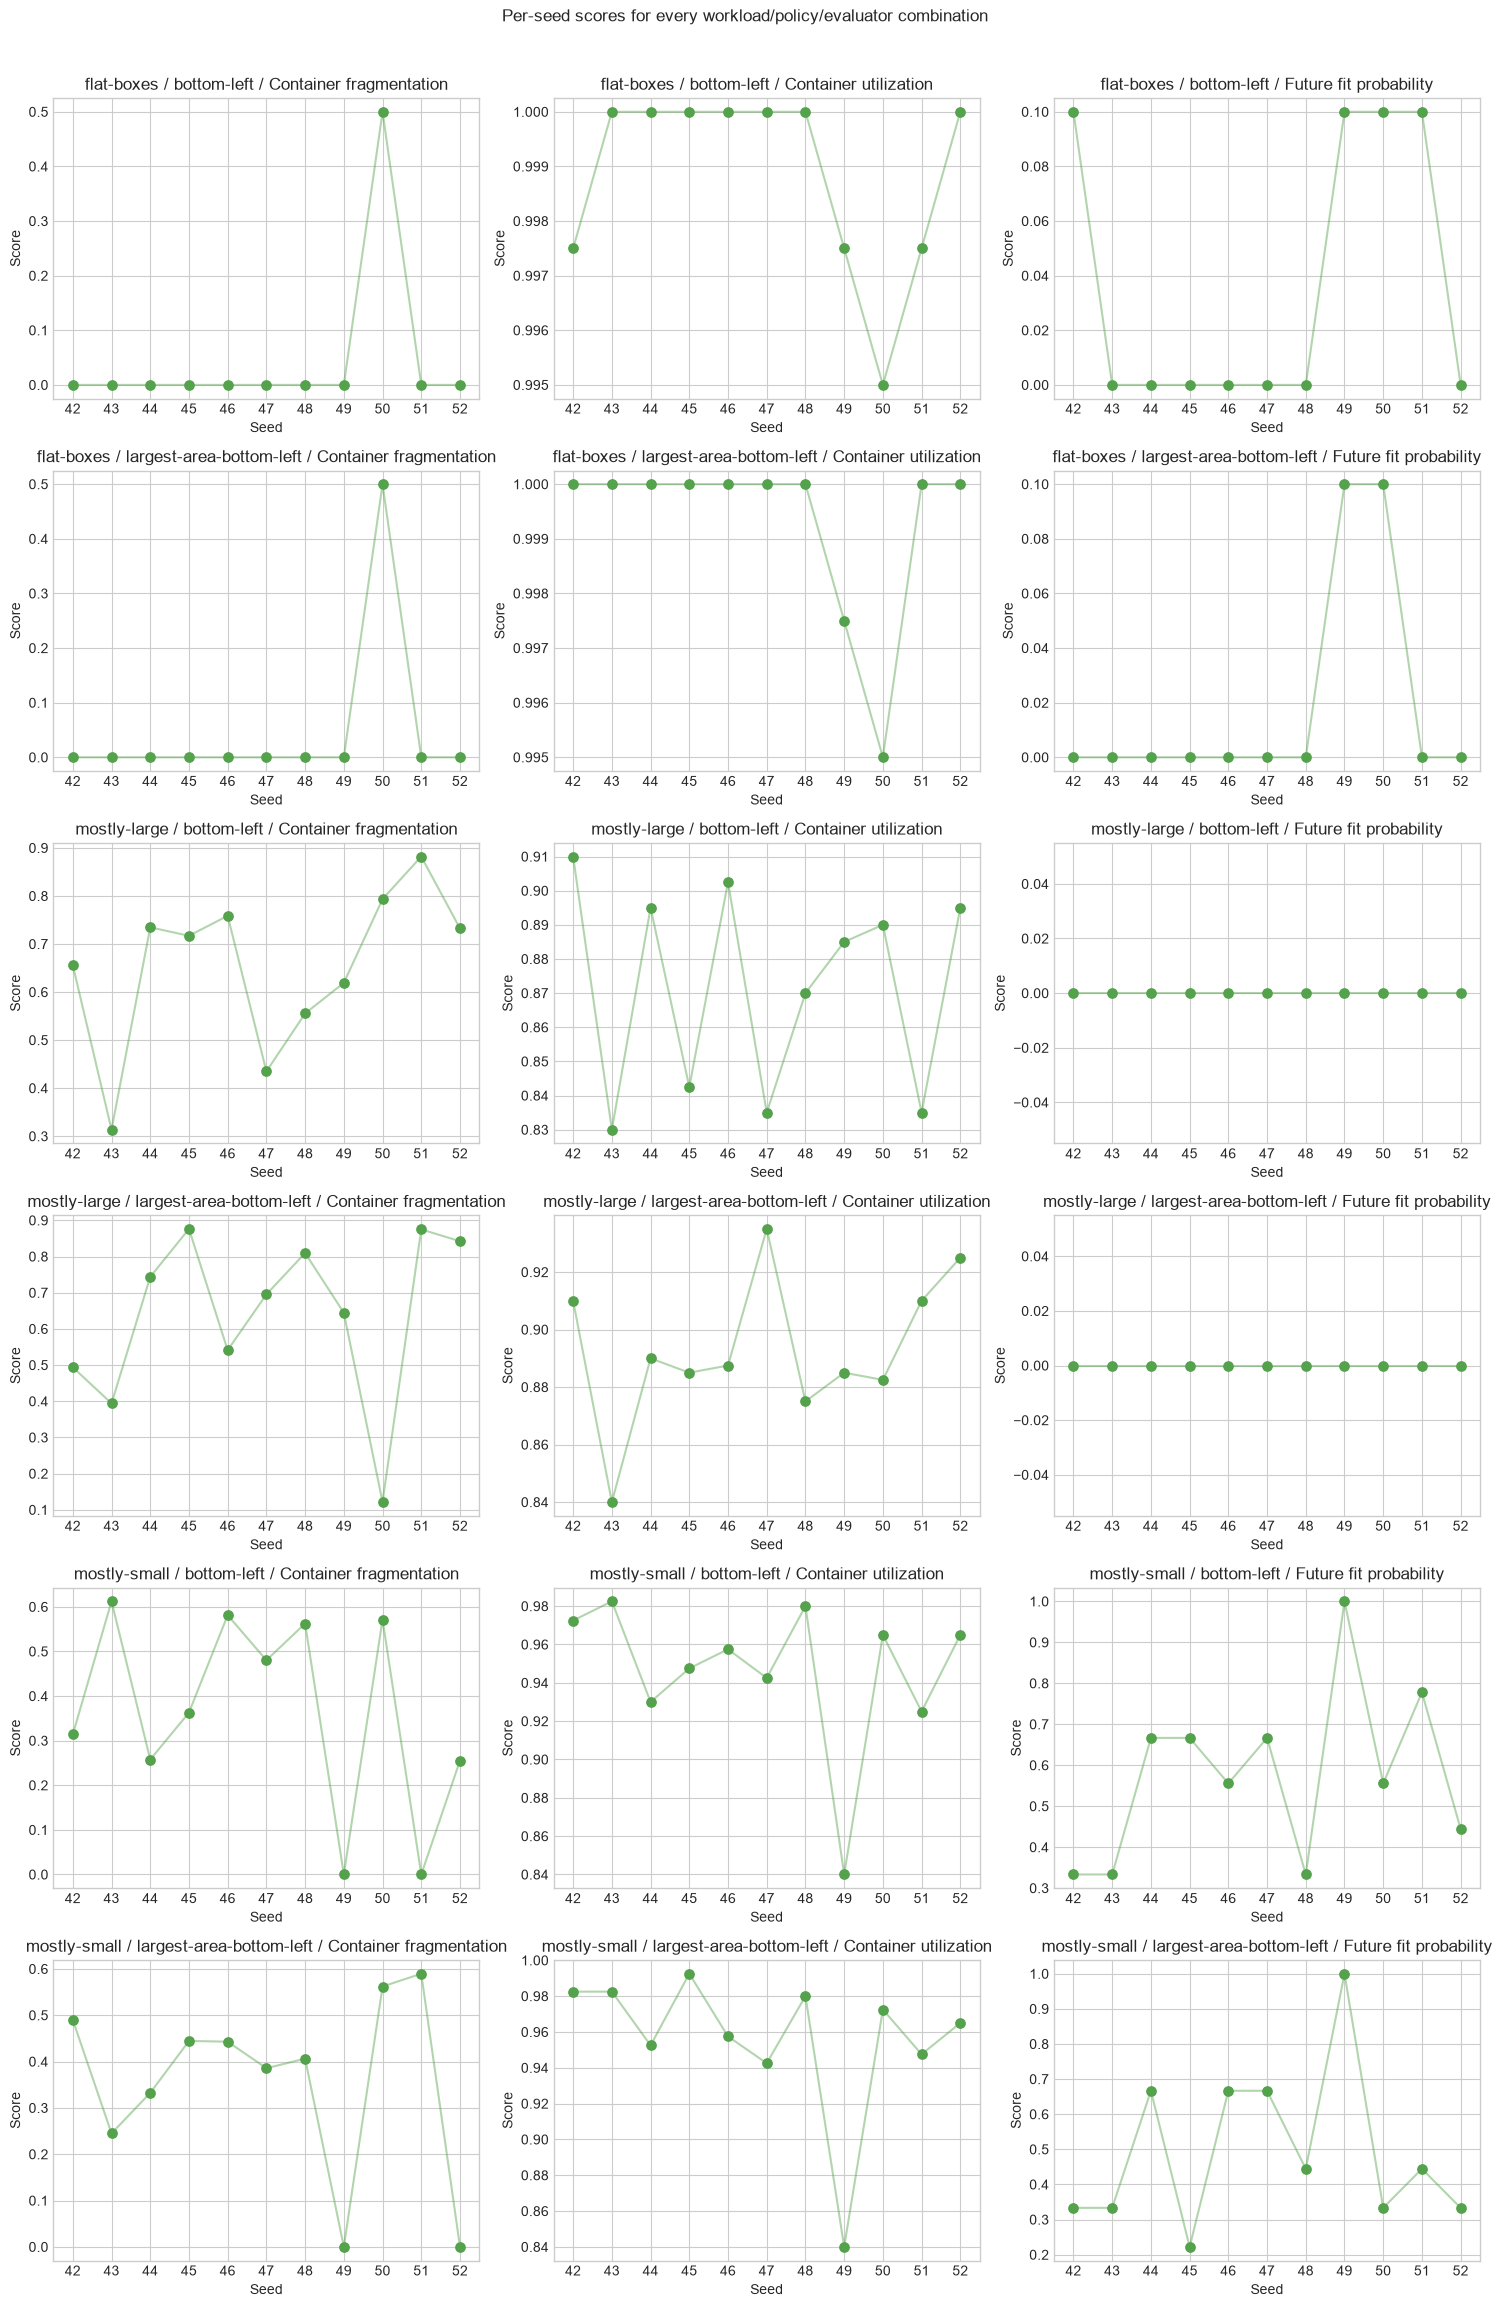

In [23]:
row_pairs = [(workload_name, policy_name) for workload_name in workloads for policy_name in policies]
fig, axes = plt.subplots(
    len(row_pairs), len(evaluators), squeeze=False, figsize=(5 * len(evaluators), 3.8 * len(row_pairs))
)
for row, (workload_name, policy_name) in enumerate(row_pairs):
    for col, evaluator_name in enumerate(evaluators):
        ax = axes[row, col]
        seed_scores = runs[
            (runs["workload"] == workload_name)
            & (runs["policy"] == policy_name)
            & (runs["evaluation"] == evaluator_name)
        ].sort_values("seed")
        if seed_scores.empty:
            ax.set_axis_off()
            continue
        ax.scatter(seed_scores["seed"], seed_scores["value"], s=45, color="#54A24B", zorder=3)
        ax.plot(seed_scores["seed"], seed_scores["value"], color="#54A24B", alpha=0.45)
        ax.set(
            title=f"{workload_name} / {policy_name} / {evaluator_name}",
            xlabel="Seed",
            ylabel="Score",
        )
        ax.set_xticks(seed_scores["seed"])
fig.suptitle("Per-seed scores for every workload/policy/evaluator combination", y=1.01)
fig.tight_layout()
plt.show()